# Iniciación en análisis de datos con Python

**Mayo 2026 · Bloque I**

## Objetivos
- Configurar el entorno de trabajo en Jupyter/VS Code
- Cargar, explorar y limpiar datos con pandas
- Construir un análisis descriptivo reproducible

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga de datos y primera inspección

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

DATA_DIR = Path("../data")
pd.set_option("display.max_columns", 50)

df = pd.read_csv(DATA_DIR / "ventas_mayo_2026.csv", parse_dates=["fecha"])
display(df.head())
df.info()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.92,0.07,63,836.25
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.95,0.10,52,956.72
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.77,0.05,26,357.65
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.17,0.06,53,301.52
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.09,29,2101.55


<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     505 non-null    datetime64[us]
 1   cliente_id                505 non-null    str           
 2   categoria                 505 non-null    str           
 3   region                    495 non-null    str           
 4   canal                     505 non-null    str           
 5   unidades                  505 non-null    int64         
 6   precio_unitario           490 non-null    float64       
 7   descuento                 505 non-null    float64       
 8   antiguedad_cliente_meses  505 non-null    int64         
 9   importe                   505 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(4)
memory usage: 39.6 KB


## Limpieza básica y tipos de datos

In [2]:
df_clean = df.copy()

# Verificar qué columnas existen
print("Columnas disponibles:", df_clean.columns.tolist())

# Rellenar valores nulos en columnas categóricas
for col in ["categoria", "region", "canal"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("desconocido")

# Rellenar valores nulos en columnas numéricas
for col in ["importe", "unidades", "precio_unitario"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Crear variable derivada: precio con descuento
if "precio_unitario" in df_clean.columns and "descuento" in df_clean.columns:
    df_clean["precio_final"] = df_clean["precio_unitario"] * (1 - df_clean["descuento"])
    df_clean["ticket_unitario"] = df_clean["importe"] / df_clean["unidades"]

display(df_clean.head())

Columnas disponibles: ['fecha', 'cliente_id', 'categoria', 'region', 'canal', 'unidades', 'precio_unitario', 'descuento', 'antiguedad_cliente_meses', 'importe']


,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,precio_final,ticket_unitario
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.07,63,836.25,92.92560,104.531250
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.10,52,956.72,173.65500,191.344000
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.05,26,357.65,37.78150,51.092857
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.06,53,301.52,23.65980,33.502222
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.305,0.09,29,2101.55,107.65755,262.693750


## Agrupaciones y visualización

,region,canal,ventas_totales,clientes,ticket_medio
13,Valencia,Online,65071.67,47,1355.659792
1,Andalucía,Online,57048.07,45,1267.734889
10,Madrid,Online,53686.76,40,1342.169000
2,Andalucía,Tienda,47792.49,41,1111.453256
8,Cataluña,Tienda,44737.92,38,1177.313684
9,Madrid,Distribuidor,42745.16,28,1473.971034
4,Castilla-La Mancha,Online,41781.63,38,1099.516579
5,Castilla-La Mancha,Tienda,40766.73,27,1509.878889
14,Valencia,Tienda,40195.31,37,1086.359730
7,Cataluña,Online,39566.24,39,1014.518974


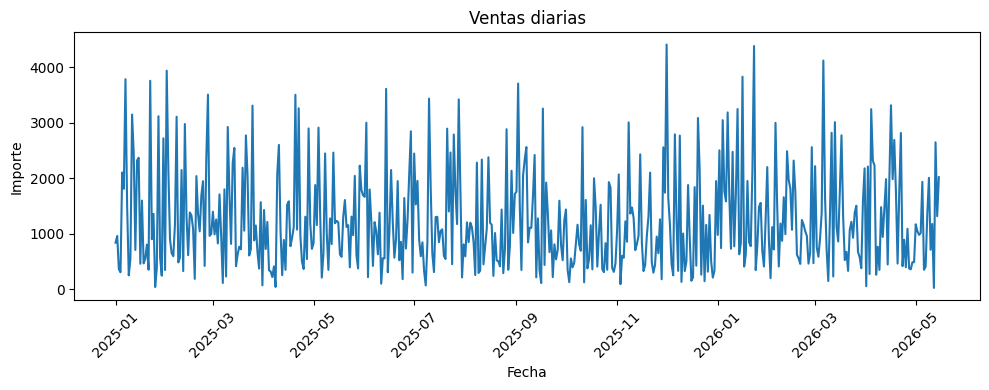

In [3]:
resumen = df_clean.groupby(["region","canal"], as_index=False).agg(
    ventas_totales=("importe","sum"),
    clientes=("cliente_id","nunique"),
    ticket_medio=("importe","mean")
).sort_values("ventas_totales", ascending=False)
display(resumen.head(10))

ventas_dia = df_clean.groupby("fecha")["importe"].sum()
if HAS_MATPLOTLIB:
    plt.figure(figsize=(10,4))
    plt.plot(ventas_dia.index, ventas_dia.values)
    plt.title("Ventas diarias")
    plt.xlabel("Fecha")
    plt.ylabel("Importe")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib no disponible")
    display(ventas_dia.head(10))

## Mini-reto

In [4]:
# Reto: identifica el canal con mayor importe total y argumenta qué región genera más ventas.
display(df_clean.groupby("canal").agg(
    importe_total=("importe","sum"),
    ticket_medio=("importe","mean"),
    operaciones=("cliente_id","count")
).sort_values("importe_total", ascending=False))

,importe_total,ticket_medio,operaciones
canal,,,
Online,261714.70,1234.503302,212
Tienda,220526.13,1160.663842,190
Distribuidor,137286.52,1332.878835,103


## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.